<a href="https://colab.research.google.com/github/ArnabManna-oss/ACT-course-/blob/main/ppe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhranilghosh07/construction-ppe")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'construction-ppe' dataset.
Path to dataset files: /kaggle/input/construction-ppe


In [3]:
!pip install ultralytics -q

In [4]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [5]:
path = "/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data"

train_images = os.path.join(path, "train/images")
train_labels = os.path.join(path, "train/labels")

train_images = os.path.join(path, "train/images")
train_labels = os.path.join(path, "train/labels")

val_images = os.path.join(path, "valid/images")
val_labels = os.path.join(path, "valid/labels")

test_images = os.path.join(path, "test/images")
test_labels = os.path.join(path, "test/labels")

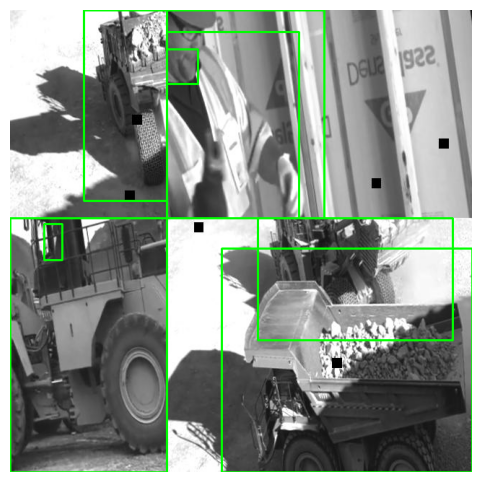

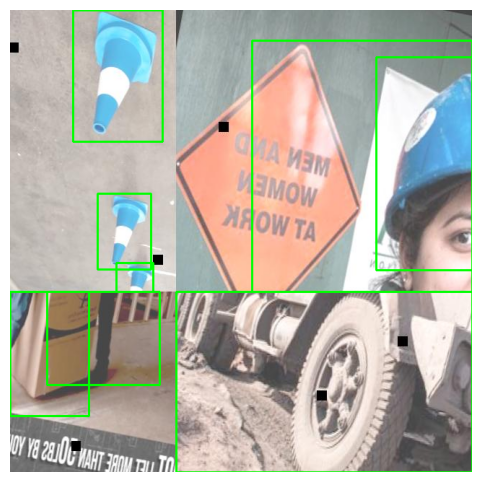

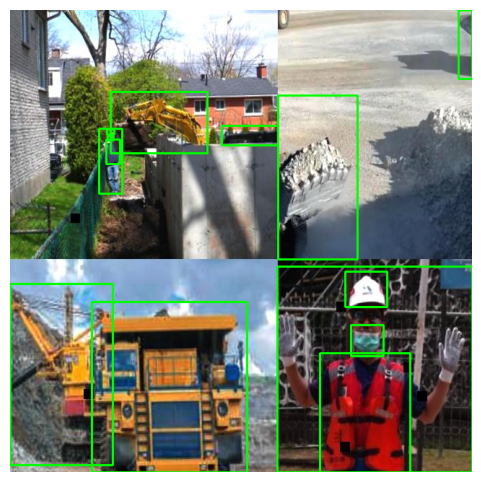

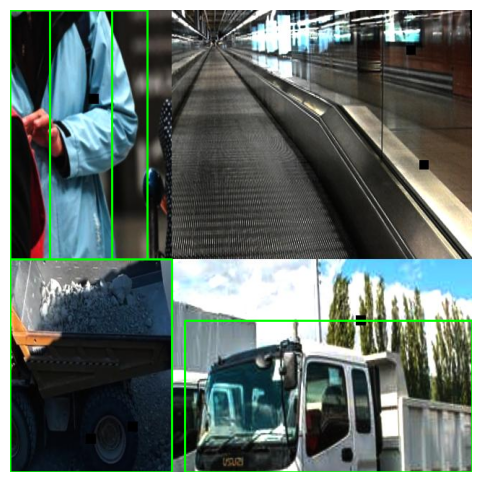

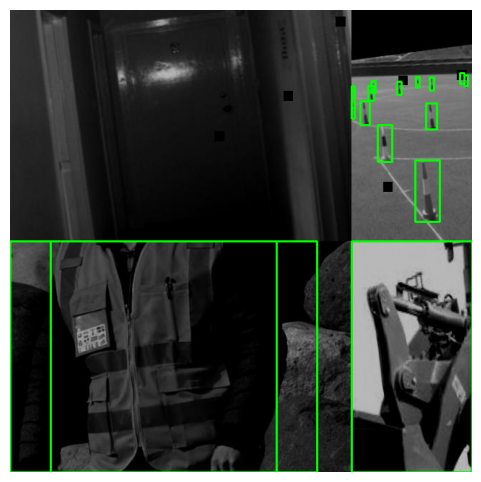

In [6]:
def show_random_images(image_dir, label_dir, num_images=5):
    images = random.sample(os.listdir(image_dir), num_images)

    for img_name in images:
        img_path = os.path.join(image_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

# Re-evaluate train_images and train_labels with the correct base path
train_images = os.path.join(path, "train/images")
train_labels = os.path.join(path, "train/labels")

show_random_images(train_images, train_labels)

In [7]:
model = YOLO("yolov8n.pt")

In [20]:
# model.train(
#     data="/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/data.yaml",
#     epochs=30,        # not too high (CPU is slow)
#     imgsz=320,        # smaller image = faster
#     batch=2,          # IMPORTANT for CPU
#     workers=2,        # safe for i3
#     name="ppe_cpu",
#     device="cpu"
# )

In [9]:
model.train(
    data="/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/data.yaml",
    epochs=30,
    imgsz=320,
    batch=16,
    device=0,
    workers=4,
    amp=True,
    cache=True,
    name="ppe_gpu"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_gp

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5f9c258500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [8]:
# import torch

# print("CUDA Available:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [ ]:
# !nvidia-smi

In [ ]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


# Validation

In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 907.5±427.3 MB/s, size: 51.7 KB)
val: Scanning /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 34.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.6s
                   all        114        697      0.837      0.606      0.669      0.356
               Hardhat         42         79      0.902      0.684      0.754       0.43
                  Mask         19         21          1       0.81      0.843      0.506
            NO-Hardhat         37         69      0.858      0.493      0.576      0.196
               NO-Mask         44    

# test interface

In [11]:
results = model.predict(
    source=test_images,
    save=True,
    conf=0.25
)


image 1/82 /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 320x320 1 Person, 5.9ms
image 2/82 /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 320x320 3 Hardhats, 1 NO-Mask, 1 NO-Safety Vest, 3 Persons, 6.0ms
image 3/82 /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 320x320 2 Hardhats, 2 NO-Safety Vests, 3 Persons, 1 machinery, 6.7ms
image 4/82 /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 320x320 1 Hardhat, 1 Mask, 2 NO-Masks, 1 NO-Safety V

# Show prediction

In [12]:
import glob

pred_images = glob.glob("runs/detect/ppe_detection*/predict/*.jpg")

for img_path in pred_images[:5]:
    img = cv2.imread(img_path)
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Evaluate on test sets

In [14]:
model.val(data="/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/data.yaml", split="test")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1469.4±294.4 MB/s, size: 57.7 KB)
val: Scanning /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 1.6Kit/s 0.0s
val: New cache created: /root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3it/s 4.5s
                   all         82        760      0.773      0.523      0.584      0.301
               Hardhat         30        110      0.886      0.664      0.728      0.388
                  Mask         16         28      0.941      0.571      0.724      0.362
            NO-Hardhat         25         41       0.7

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5f7c56ea80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

# plot metrics

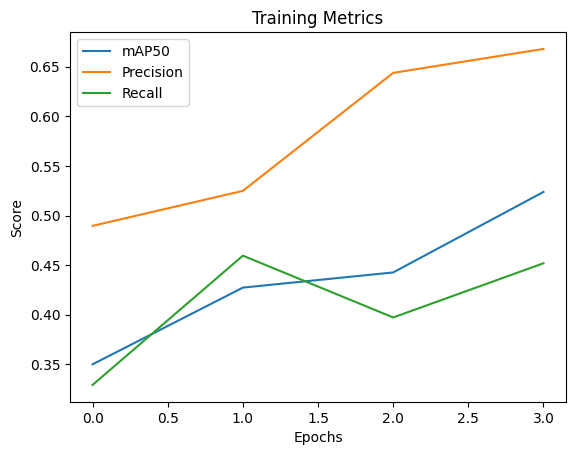


 Final Metrics (Last Epoch):
mAP@0.5     : 0.5238
Precision   : 0.6679
Recall      : 0.4519


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

log_path = "/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/runs/detect/train/results.csv"

df = pd.read_csv(log_path)

#  Plot
plt.plot(df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['metrics/precision(B)'], label='Precision')
plt.plot(df['metrics/recall(B)'], label='Recall')

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.title("Training Metrics")
plt.show()

#  Final values (last epoch)
final_map50 = df['metrics/mAP50(B)'].iloc[-1]
final_precision = df['metrics/precision(B)'].iloc[-1]
final_recall = df['metrics/recall(B)'].iloc[-1]

print("\n Final Metrics (Last Epoch):")
print(f"mAP@0.5     : {final_map50:.4f}")
print(f"Precision   : {final_precision:.4f}")
print(f"Recall      : {final_recall:.4f}")

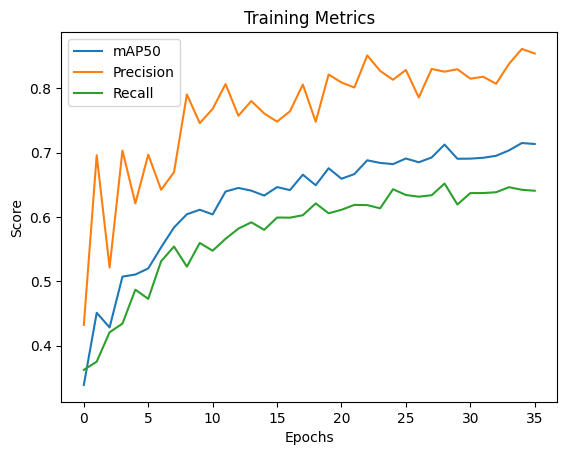


 Final Metrics (Last Epoch):
mAP@0.5     : 0.7134
Precision   : 0.8541
Recall      : 0.6407


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

log_path = "/root/.cache/kagglehub/datasets/subhranilghosh07/construction-ppe/versions/1/Construction-Site-Safety-PPE-Detection/runs/detect/train2/results.csv"

df = pd.read_csv(log_path)

#  Plot
plt.plot(df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['metrics/precision(B)'], label='Precision')
plt.plot(df['metrics/recall(B)'], label='Recall')

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.title("Training Metrics")
plt.show()

#  Final values (last epoch)
final_map50 = df['metrics/mAP50(B)'].iloc[-1]
final_precision = df['metrics/precision(B)'].iloc[-1]
final_recall = df['metrics/recall(B)'].iloc[-1]

print("\n Final Metrics (Last Epoch):")
print(f"mAP@0.5     : {final_map50:.4f}")
print(f"Precision   : {final_precision:.4f}")
print(f"Recall      : {final_recall:.4f}")